In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import uncertainties as unc
import glob

In [6]:
data_file_names = glob.glob(r"C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\*homing_data*.csv")

DF_list = []
for name in data_file_names:
    DF = pd.read_csv(name)
    DF_list.append(DF)
    print(f"File: {name} has {DF.shape[0]} rows and {DF.shape[1]} columns.")

data = pd.concat(DF_list, ignore_index=True)
print(data.head())

File: C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE_homing_data_20251112-120106.csv has 1000 rows and 4 columns.
File: C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE_homing_data_20251112-134146.csv has 1000 rows and 4 columns.
File: C:\Users\Jason.Bane\Documents\Nautilus\DOE_stage\code_trials\data\DOE_homing_data_20251112-154340.csv has 999 rows and 4 columns.
      Angle   Error  Success  Quailty
0  193.3643  0.0858     True     0.88
1  193.5441  0.6834     True     0.99
2  193.1696  0.3364     True     1.00
3  193.3768  0.7324     True     0.89
4  193.7518  0.0895     True     0.97


Average Angle: 193.5+/-0.2
Max Angle: 194.3381, Min Angle: 191.7804


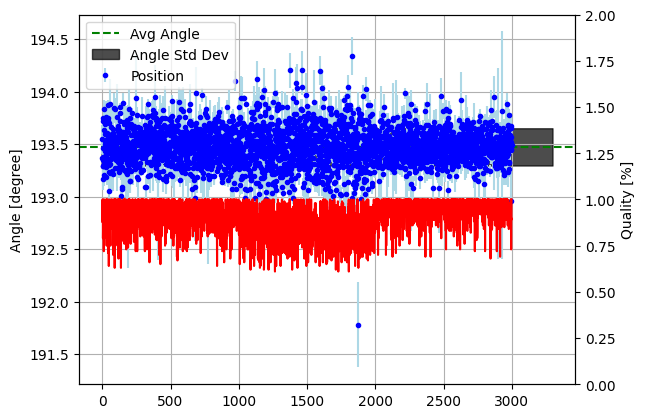

In [ ]:
fig,ax = plt.subplots()


ax.errorbar(data.index, data['Angle'], yerr=data["Error"]/5, fmt='.', color="blue", ecolor="lightblue", label='Position')


avg_angle = unc.ufloat(np.mean(data['Angle']), np.std(data['Angle']))



print(f"Average Angle: {avg_angle:.1f}")
print(f"Max Angle: {np.max(data['Angle'])}, Min Angle: {np.min(data['Angle'])}")



ax.axhline(avg_angle.n, color='g', linestyle='--', label='Avg Angle')
ax.fill_between(np.arange(-5,data.index[-1]*1.1,0.1), avg_angle.n - avg_angle.s, avg_angle.n + avg_angle.s, color='black', alpha=0.7, label='Angle Std Dev')

#make second y axis
ax2 = ax.twinx()
ax2.set_ylabel("Quality [%]")
ax2.set_ylim(0, 2)
ax2.plot(data.index, data['Quailty'], 'r-', label='Quality')


ax.set_ylabel("Angle [degree]")
ax.legend(loc='upper left')
# ax.set_ylim(185,197)
ax.grid()


Fitted mu: 193.5 ± 0.2


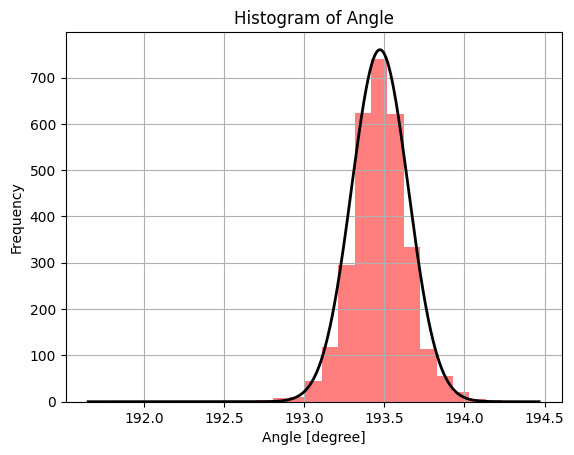

In [8]:
fig,ax = plt.subplots()

#histogram of Angle

ax.hist(data['Angle'], bins=25, alpha=0.5, color='red')
ax.set_xlabel("Angle [degree]")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of Angle")

#fit a normal distribution curve
from scipy.stats import norm 
mu, std = norm.fit(data['Angle'])
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 1000)
p = norm.pdf(x, mu, std)
ax.plot(x, p * len(data['Angle']) * (xmax - xmin) / 25, 'k', linewidth=2)
# ax.set_yscale('log')
print(f"Fitted mu: {mu:.1f} ± {std:.1f}")

ax.grid()
# ax.set_xlim(180,200)

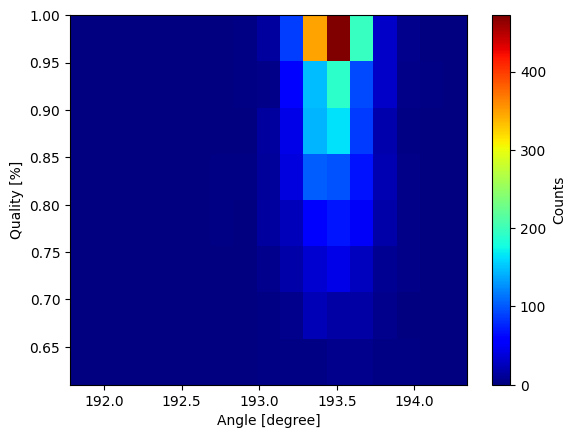

In [9]:
fig,ax = plt.subplots()

#2d histogram of Angle vs Quality
hb = ax.hist2d(data['Angle'], data['Quailty'], bins=(17,8), cmap='jet',)

#logscale the colorbar





ax.set_xlabel("Angle [degree]")
ax.set_ylabel("Quality [%]")

fig.colorbar(hb[3], ax=ax, label='Counts', format='%d')